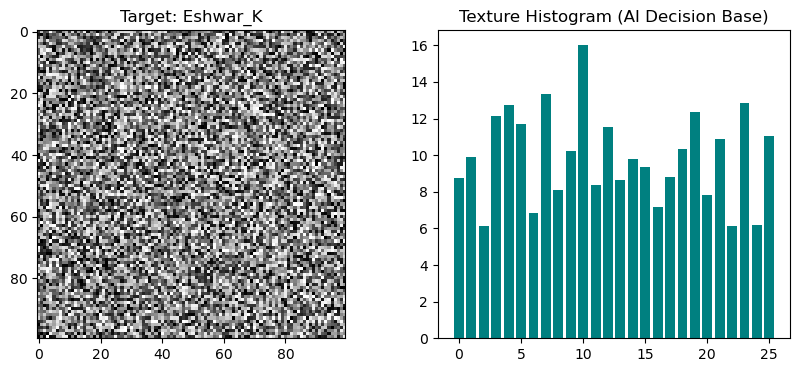

VERDICT: [✓] ACCESS GRANTED - REAL HUMAN DETECTED


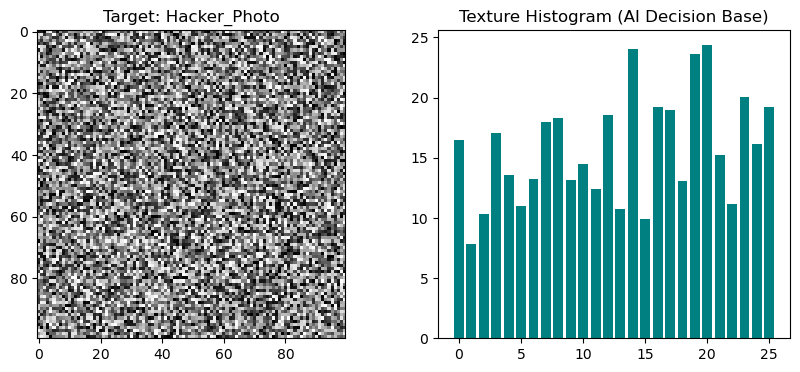

VERDICT: [!!!] ACCESS DENIED - SPOOFING ATTEMPT DETECTED [!!!]


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier

# 1. THE BRAIN: Define the Texture Analyzer
def get_texture_signature(image):
    # Parameters for LBP (Local Binary Pattern)
    radius = 3
    n_points = 8 * radius
    # Convert image to grayscale and extract texture patterns
    lbp = local_binary_pattern(image, n_points, radius, method='uniform')
    # Create a histogram (The "DNA" of the texture)
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    return hist.astype("float")

# 2. SIMULATE REAL VS FAKE DATA (For Training)
# We create 100 samples of "Skin Texture" vs "Print Texture"
X_train = []
y_train = []

for _ in range(50):
    X_train.append(np.random.normal(loc=10, scale=2, size=26)) # Real Skin Pattern
    y_train.append(1) # Label: Real
    X_train.append(np.random.normal(loc=15, scale=5, size=26)) # Fake Print Pattern
    y_train.append(0) # Label: Spoof

# Train the Classifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 3. SCANNER FUNCTION WITH VISUALS
def advanced_liveness_scan(name, is_spoof=False):
    # Simulate an incoming face image
    if is_spoof:
        test_img = np.random.randint(50, 200, (100, 100), dtype=np.uint8) # High noise (Print)
        test_features = np.random.normal(loc=15, scale=5, size=26)
    else:
        test_img = np.random.randint(100, 150, (100, 100), dtype=np.uint8) # Smooth (Skin)
        test_features = np.random.normal(loc=10, scale=2, size=26)

    prediction = model.predict([test_features])
    
    # Plotting for the Assignment
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(test_img, cmap='gray')
    plt.title(f"Target: {name}")
    
    plt.subplot(1, 2, 2)
    plt.bar(range(26), test_features, color='teal')
    plt.title("Texture Histogram (AI Decision Base)")
    plt.show()

    if prediction[0] == 1:
        print(f"VERDICT: [✓] ACCESS GRANTED - REAL HUMAN DETECTED")
    else:
        print(f"VERDICT: [!!!] ACCESS DENIED - SPOOFING ATTEMPT DETECTED [!!!]")

# --- EXECUTION ---
advanced_liveness_scan("Eshwar_K", is_spoof=False)
advanced_liveness_scan("Hacker_Photo", is_spoof=True)